In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# **ΜΕΡΟΣ Α**

In [4]:
df = pd.read_csv("superstore_project_unclean.csv")


In [5]:
print(df.head())
print("Shape:", df.shape)

   Row ID        Order_ID  Order Date   Ship Date       Ship Mode Customer ID  \
0    8325  CA-2017-144456    9/8/2017    9/9/2017     First Class    FC-14245   
1    3636  CA-2016-145177  11/10/2016  11/14/2016  Standard Class    PP-18955   
2    9378  CA-2017-155362  12/17/2017  12/21/2017  Standard Class    DP-13105   
3    4897  CA-2016-135776  12/23/2016  12/30/2016  Standard Class    EH-13765   
4    8442  CA-2017-145779    5/6/2017   5/10/2017  Standard Class    DB-13615   

    Customer Name      Segment        Country         City  ... Postal Code  \
0  Frank Carlisle  Home Office  United States      Hialeah  ...       33012   
1      Paul Prost  Home Office  United States  Springfield  ...       45503   
2    Dave Poirier    Corporate  United States   Eau Claire  ...       54703   
3    Edward Hooks    Corporate  United States      Seattle  ...       98103   
4   Doug Bickford     Consumer  United States       Tucson  ...       85705   

    Region       Product ID         Ca

In [6]:
df.info()

print("\nΚενές τιμές:")
print(df.isna().sum())

print("\nΔιπλότυπες γραμμές:")
print(df.duplicated().sum())

print("\nΚατηγορια:")
print(df["Category"].value_counts())

print("\nΠεριοχη:")
print(df["Region"].value_counts())

print("\nΤρόπος αποστολής:")
print(df["Ship Mode"].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10006 entries, 0 to 10005
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         10006 non-null  int64  
 1   Order_ID       10006 non-null  object 
 2   Order Date     10006 non-null  object 
 3   Ship Date      10006 non-null  object 
 4   Ship Mode      10006 non-null  object 
 5   Customer ID    10006 non-null  object 
 6   Customer Name  10006 non-null  object 
 7   Segment        10006 non-null  object 
 8   Country        10006 non-null  object 
 9   City           10006 non-null  object 
 10  State          10006 non-null  object 
 11  Postal Code    10006 non-null  int64  
 12  Region         10006 non-null  object 
 13  Product ID     10006 non-null  object 
 14  Category       9998 non-null   object 
 15  Sub Category   10006 non-null  object 
 16  Product Name   10006 non-null  object 
 17  Sales          9994 non-null   float64
 18  Quanti

# ΜΕΡΟΣ *Β*

In [7]:
df = df.rename (
    columns ={
         "Order_ID" : "Order ID",
         "Sub Category" : "Sub-Category"
             }
               )
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [8]:
print("Γραμμές πριν:", df.shape[0])
df =df.drop_duplicates()
print("Γραμμές μετά:", df.shape[0])

Γραμμές πριν: 10006
Γραμμές μετά: 9994


In [9]:
df["Category"] = df["Category"].str.strip().str.title()
df["Region"] = df["Region"].str.strip().str.title()
df["Ship Mode"] = df["Ship Mode"].str.strip().str.title()

print(df["Category"].value_counts())
print(df["Region"].value_counts())
print(df["Ship Mode"].value_counts())

Category
Office Supplies    6020
Furniture          2119
Technology         1847
Name: count, dtype: int64
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64


In [10]:
df["Quantity"]
invalid_quantities =(df["Quantity"] < 1) | (df["Quantity"] > 14)
x = df.loc[invalid_quantities, "Quantity"]
x = np.nan


In [11]:
for i in ["Sales", "Profit"]:
    df[i] = df[i].fillna(df[i].median())
    print(f"{i} συμπληρώθηκε, κενές τιμές: {df[i].isna().sum()}")

stat_quantity = round(df["Quantity"].median())
df["Quantity"] = df["Quantity"].fillna(stat_quantity)
df["Quantity"] = df["Quantity"].astype(int)
print(df["Quantity"])

mode_category = df["Category"].mode()[0]
df["Category"] = df["Category"].fillna(mode_category)
print(df["Category"])

Sales συμπληρώθηκε, κενές τιμές: 0
Profit συμπληρώθηκε, κενές τιμές: 0
0        5
1        2
2        2
3        4
4        4
        ..
10001    2
10002    2
10003    3
10004    2
10005    2
Name: Quantity, Length: 9994, dtype: int64
0        Office Supplies
1        Office Supplies
2        Office Supplies
3        Office Supplies
4        Office Supplies
              ...       
10001          Furniture
10002    Office Supplies
10003    Office Supplies
10004    Office Supplies
10005          Furniture
Name: Category, Length: 9994, dtype: object


In [12]:
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])
print(df["Order Date"].dtype)
print(df["Ship Date"].dtype)

datetime64[ns]
datetime64[ns]


In [13]:
df["Country"].nunique()
df = df.drop(columns=["Country"])
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [14]:
print("Το τελικό σχήμα είναι:", df.shape)
print("Οι συνολικές κενές τιμές είναι:", df.isna().sum().sum())
print("Διπλότυπα:", df.duplicated().sum())
print("Η μέγιστη ποσότητα είναι:", df["Quantity"].max())
print("Η ελάχιστη ποσότητα είναι:", df["Quantity"].min())

Το τελικό σχήμα είναι: (9994, 20)
Οι συνολικές κενές τιμές είναι: 0
Διπλότυπα: 0
Η μέγιστη ποσότητα είναι: 99
Η ελάχιστη ποσότητα είναι: -2


# ΜΕΡΟΣ **C**

In [15]:
order_count = df["Order ID"].nunique()
customer_count = df["Customer ID"].nunique()
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
profit_margin = total_profit / total_sales * 100

print("Αριθμός των Παραγγελίων:",order_count)
print("Αριθμός των Πελατών:",customer_count)
print("Συνολικές πωλήσεις:",total_sales)
print("Συνολικά Κέρδη:", total_profit)
print("Συνολικό Περιθώριο Κέρδους:", profit_margin)

Αριθμός των Παραγγελίων: 5009
Αριθμός των Πελατών: 793
Συνολικές πωλήσεις: 2295124.1083
Συνολικά Κέρδη: 286414.6265
Συνολικό Περιθώριο Κέρδους: 12.4792653026571


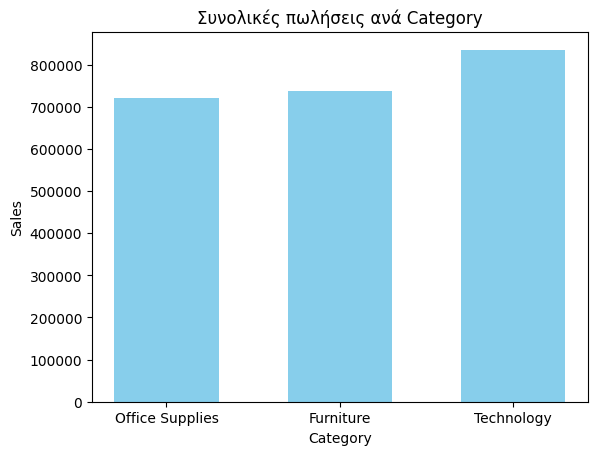

In [16]:
sales_per_category = df.groupby("Category")["Sales"].sum()
sales_per_category = sales_per_category.sort_values()
plt.bar(sales_per_category.index,sales_per_category.values, color="skyblue",width=0.6)
plt.title("Συνολικές πωλήσεις ανά Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()


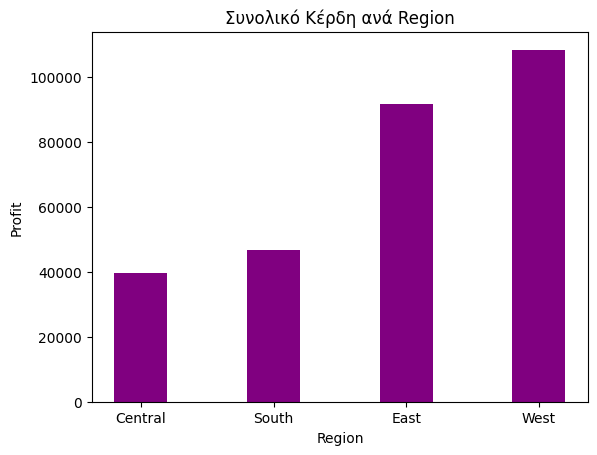

In [17]:
profit_per_region = df.groupby("Region")["Profit"].sum()
profit_per_region = profit_per_region.sort_values()
plt.bar(profit_per_region.index,profit_per_region.values,color="purple",width=0.4)
plt.title("Συνολικό Κέρδη ανά Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

count     9994.000000
mean       229.650201
std        623.185229
min          0.444000
25%         17.310000
50%         54.490000
75%        209.858000
max      22638.480000
Name: Sales, dtype: float64


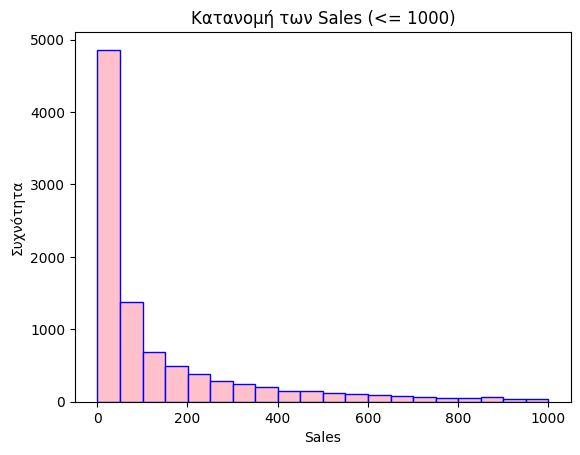

In [18]:
print(df["Sales"].describe())
filtered_sales = df[df["Sales"] <= 1000]["Sales"]
plt.hist(filtered_sales,bins=20,color="pink",edgecolor="blue")
plt.title("Κατανομή των Sales (<= 1000)")
plt.xlabel("Sales")
plt.ylabel("Συχνότητα")
plt.show()

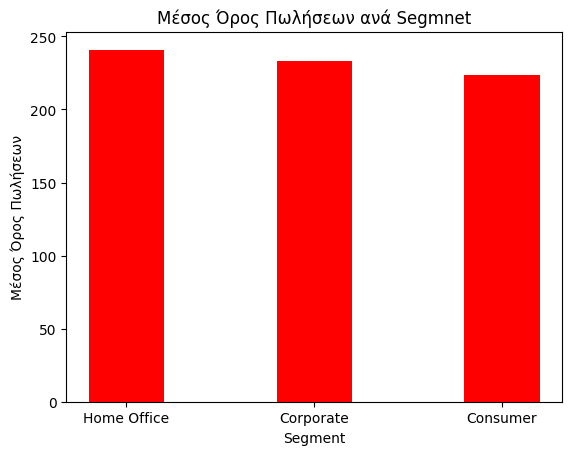

In [19]:
ave_sales_per_segment = df.groupby("Segment")["Sales"].mean()
ave_sales_per_segment = ave_sales_per_segment.sort_values(ascending=False)
plt.bar(ave_sales_per_segment.index, ave_sales_per_segment.values, color="red",width=0.4)
plt.title("Μέσος Όρος Πωλήσεων ανά Segmnet")
plt.xlabel("Segment")
plt.ylabel("Μέσος Όρος Πωλήσεων")
plt.show()

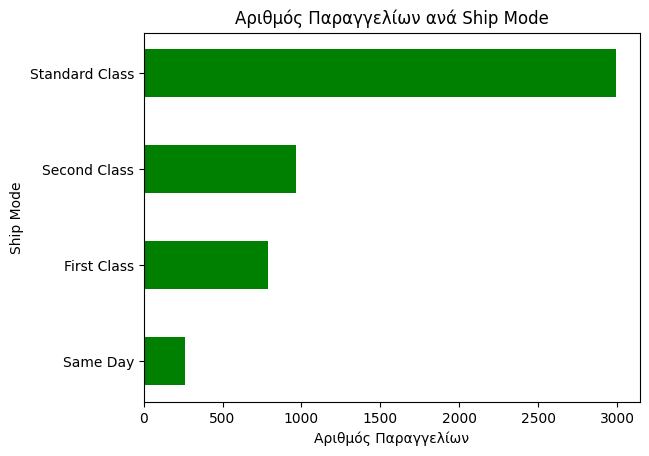

In [20]:
order_count_per_ship_mode = df.groupby("Ship Mode")["Order ID"].nunique()
order_count_per_ship_mode = order_count_per_ship_mode.sort_values()
plt.barh(order_count_per_ship_mode.index, order_count_per_ship_mode.values, color="green",height=0.5)
plt.title("Αριθμός Παραγγελίων ανά Ship Mode")
plt.xlabel("Αριθμός Παραγγελίων")
plt.ylabel("Ship Mode")
plt.show()

# ΜΕΡΟΣ **D**

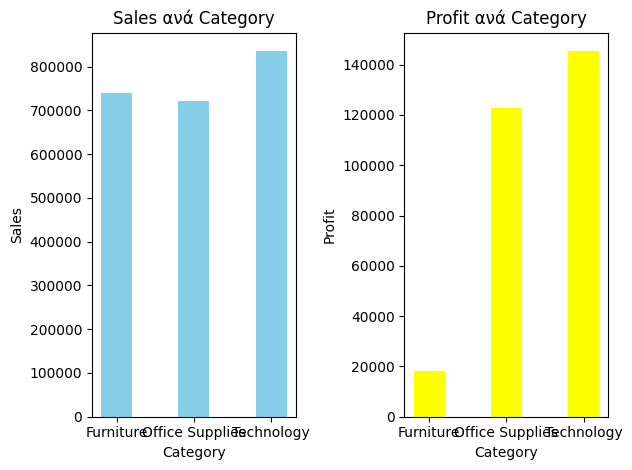

In [21]:
sales_by_category = df.groupby("Category")["Sales"].sum()
profit_by_category = df.groupby("Category")["Profit"].sum()
category_summary = pd.DataFrame(
    {"Total_Sales": sales_by_category,
     "Total_Profit": profit_by_category
    }
)
plt.subplot(1, 2, 1)
plt.bar(category_summary.index, category_summary["Total_Sales"], color="skyblue", width=0.4)
plt.title("Sales ανά Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.subplot(1, 2, 2)
plt.bar(category_summary.index, category_summary["Total_Profit"], color="yellow",width = 0.4)
plt.title("Profit ανά Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

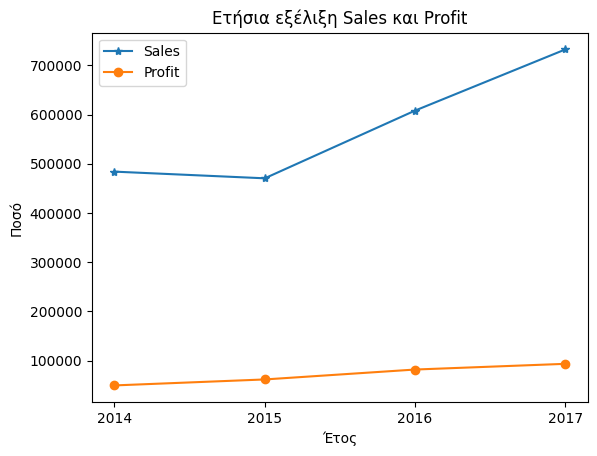

In [22]:
Order_Year = df["Order Date"].dt.year
Sales_per_Year = df.groupby(Order_Year)["Sales"].sum()
Profit_per_Year = df.groupby(Order_Year)["Profit"].sum()

plt.plot(Sales_per_Year.index, Sales_per_Year.values, marker="*", label="Sales")
plt.plot(Profit_per_Year.index, Profit_per_Year.values, marker="o", label="Profit")

plt.xticks(Sales_per_Year.index)

plt.title("Ετήσια εξέλιξη Sales και Profit")
plt.xlabel("Έτος")
plt.ylabel("Ποσό")
plt.legend()
plt.show()

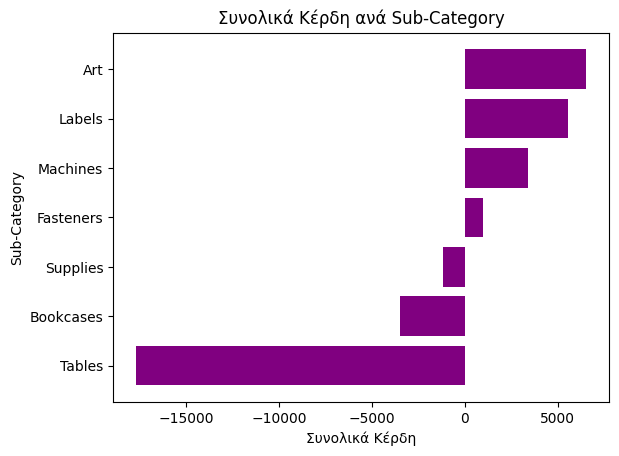

In [23]:
profit_per_sub_category = df.groupby("Sub-Category")["Profit"].sum()
profit_per_sub_category = profit_per_sub_category.sort_values()
profit_per_sub_category = profit_per_sub_category.head(7)
plt.barh(profit_per_sub_category.index, profit_per_sub_category.values, color="purple")
plt.title("Συνολικά Κέρδη ανά Sub-Category")
plt.xlabel("Συνολικά Κέρδη")
plt.ylabel("Sub-Category")
plt.show()

**ΑΠΑΝΤΗΣΗ ΕΡΩΤΗΣΗΣ:**
Οι υποκατηγορίες Supplies, Bookcases και Tables προκαλούν ζημίες, καθώς τα συνολικά τους κέρδη είναι αρνητικά.


Text(0, 0.5, 'Συνολικά Κέρδη')

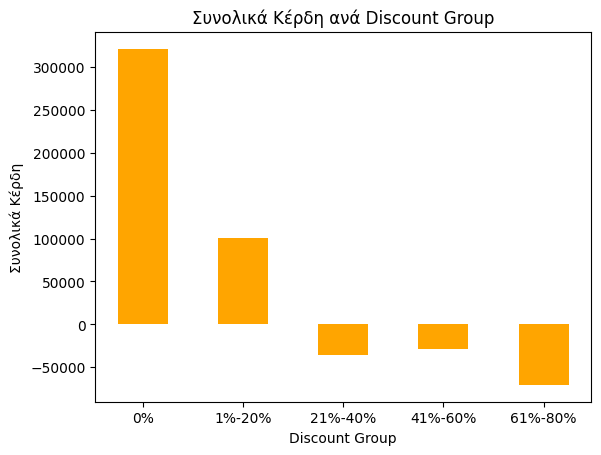

In [24]:
bins = [-0.01, 0 , 0.20, 0.40, 0.60, 0.80]
labels = ["0%", "1%-20%", "21%-40%", "41%-60%", "61%-80%"]
df["Discount Group"] = pd.cut(df["Discount"], bins=bins, labels=labels)
df["Discount Group"] = df["Discount Group"].astype(str)
discount_group_profit = df.groupby("Discount Group")["Profit"].sum()
plt.bar(discount_group_profit.index, discount_group_profit.values, color="orange",width=0.5)
plt.title("Συνολικά Κέρδη ανά Discount Group")
plt.xlabel("Discount Group")
plt.ylabel("Συνολικά Κέρδη")

**ΑΠΑΝΤΗΣΗ ΕΡΩΤΗΣΗΣ**:
Εμφανίζονται συνολικές ζημιές απο το επίπεδο έκπτωσης 1%-20%.

# **ΜΕΡΟΣ E**

**ΕΡΩΤΗΣΕΙΣ:**
1. Ποιά κατηγορία έχει τις περισσότερες πωλήσεις;
2. Ποιά περιοχή έχει το μεγαλύτερο συνολικό κέρδος;
3. Πώς εξελίσσονται οι πωλήσεις και το κέρδοσ ανά έτος;
4. Ποιές υποκατηγορίες προκαλούν ζημίες;
5. Πώς συνδέεται το ύψος της έκπτωσης με το συνολικό κέρδος;
6. Ποιές κατηγορίες ή υποκατηγορίες χρειάζονται περαιτέρω διερεύνηση;

ΑΠΑΝΤΗΣΕΙΣ:
1. Η κατηγορία με τις περισσότερες πωλήσεις είναι η Technology
2. Η δυτική περιοχή (WEST) έχει το μεγαλύτερο συνολικό κέρδος
3. Οι πωλήσεις φαίνεται στην αρχή να παρουσιάζουν μια μικρή πτώση(λίγο πιο κάτω από 50.000) ενω στη συνέχεια υπάρχει μια απότομη αυξανόμενη τάση(λίγο πιο πάνω απο 70.000) με βάση τη καμπύλη του διαγράμματος.Το κέρδος φαίνεται να εξελίσσεται πιο σταθερά, αφού οι μεταβολλές από το ένα έτος στο άλλο είναι πολύ μικρές(λίγο πιο κάτω απο 10.000 μέχρι 10.000)
4. Οι υποκατηγορίες Supplies, Bookcases και Tables προκαλούν ζημίες, καθώς τα συνολικά τους κέρδη είναι αρνητικά.
5. Υπάρχει αρνητική σχέση μεταξύ του ύψους της έκπτωσης και του συνολικού κέρδους. Όσο μεγαλύτερη είναι η ομάδα έκπτωσης (discount group), τόσο μικρότερο και τελικά αρνητικό γίνεται το συνολικό κέρδος.
6. Η κατηγορία Furniture και οι υποκατηγορίες Supplies, Bookcases και Tables χρειάζονται περαιτέρω διερεύνηση καθώς έχουν τα λιγότερα συνολικά κέρδη και αντίστοιχα ζημιές σε σχέση με τα άλλα προιόντα στις κατηγορίες και υποκατηγορίες.

In [27]:
df.to_csv("superstore_project_cleaned.csv", index=False)